@author Nikolay Zhabchikov

Используются предобученные нейронные сети архитектуры Bert на корпусах текстов русского языка. Модели дополнительно предобучаются на описаниях из данных мониторинга. Затем с помощью косинусного сходства предсказывается категория. Такой подход позволяет использовать одну модель для предсказаний под разные категории данных (баранина, свинина, говядина и птица).

In [ ]:
import random
import torch
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sentence_transformers import SentenceTransformer
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

from tqdm import tqdm
tqdm.pandas()

In [2]:
random_seed = 42

random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

В качестве базовых моделей используются `cointegrated/rubert-tiny2` и `DeepPavlov/distilrubert-base-cased-conversational`. Эти модели претрейним с помощью Masked language modeling(MLM) на датасете содержащем описания со всех датасетов

In [4]:
mutton_df = pd.read_csv('data\monitorings_archive\Баранина.csv')
mutton_df = mutton_df[['Наименование', 'Описание']]

beef_df = pd.read_csv('data\monitorings_archive\Говядина.csv')
beef_df = beef_df[['Наименование', 'Описание']]

pig_df = pd.read_csv('data\monitorings_archive\Свинина.csv')
pig_df = pig_df[['Наименование', 'Описание']]

bird_df = pd.read_csv('data\monitorings_archive\Птица.csv')
bird_df = bird_df[['Наименование', 'Описание']]

all_df = pd.concat((mutton_df, beef_df, pig_df, bird_df), axis=0)
len(all_df)

1180007

В датасете оставим только уникальные записи. При этом очистим данные от лишних символов.

In [ ]:
def clear_for_bert(text):
    # удаление лишних символов, удаление сокращений с/х, зам./охл. и т.д.
    text = re.sub(r'([а-яА-Я\.\,]+(\/|\\)[а-яА-Я\.\,]+)', '', text)
    text = re.sub('[^а-яА-Я]+', ' ', text)
    text = text.lower().strip()

    # удаление одиночных букв, которые не являются предлогами или союзами
    words = []
    for word in text.split():
        if len(word) < 2:
            if word in 'скви':
                words.append(word)
        else:
            words.append(word)
    text = ' '.join(words)
    return text

all_df['Описание bert'] = all_df['Описание'].progress_apply(clear_for_bert)

100%|██████████| 1180007/1180007 [00:05<00:00, 232146.54it/s]


In [ ]:
# Сохранение уникальных описаний из всех датасетов в один текстовый файл

with open('tmp.txt', 'w', encoding = 'utf-8') as f:
    for rec_index, rec in all_df.iterrows():
        f.write(rec['Описание bert'] + '\n')


with open('tmp.txt') as result:
        uniqlines = set(result.readlines())
        with open('train_bert_cleaned.txt', 'w') as rmdup:
            rmdup.writelines(set(uniqlines))

os.remove('tmp.txt')

Разобьем текстовый файл с описаниями на тренировочный и тестовый (80/20).

Для претрейна воспользуемся скриптом из библиотеки transformers `https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py`

```
python run_mlm.py --model_name_or_path cointegrated/rubert-tiny2 \
    --train_file train_bert.txt \
    --validation_file test_bert.txt \
    --per_device_train_batch_size 64 \
    --per_device_eval_batch_size 64 \
    --do_train \
    --do_eval \
    --output_dir \tmp \
    --low_cpu_mem_usage True \
    --line_by_line True \
    --torch_dtype auto
```

Обучаем 40 эпох

# Предсказания

In [7]:
df = pd.read_csv('data\monitorings_archive\Птица.csv')
cls_df = pd.read_csv('data\categories\Птица_разрубы.csv', sep=';')
cls_names = cls_df['value'].unique().tolist()

In [8]:
df['Описание bert'] = df['Описание'].progress_apply(clear_for_bert)

100%|██████████| 540013/540013 [00:02<00:00, 220715.73it/s]


Загрузим предобученные модели

In [ ]:
model_loaded = SentenceTransformer('models\\rubert-tiny2', device=DEVICE)
model_loaded.eval()

cls_names_ = [clear_for_bert(name) for name in cls_names]
cls_embeddings = model_loaded.encode(cls_names_)

def preds_sim(text):
    # получение эмбеддинга описания
    text_embedding = model_loaded.encode(text)
    # сравнение косинусного сходства
    preds_similarity = cosine_similarity(text_embedding.reshape(1, -1), cls_embeddings)
    max_pos = np.argmax(preds_similarity)
    return cls_names[max_pos]

No sentence-transformers model found with name models\rubert-tiny2. Creating a new one with mean pooling.
Some weights of BertModel were not initialized from the model checkpoint at models\rubert-tiny2 and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# предсказания занимают достаточно много времени от 40 минут
df['rubert-tiny2'] = df['Описание bert'].progress_apply(preds_sim)

# Результаты

In [11]:
df = pd.read_csv('Птица_новые_алгоритмы.csv')

In [12]:
model_1_to_rubert = len(df[df['Категория'] == df['Категория rubert-tiny2']])
model_2_to_rubert = len(df[df['Новая Категория'] == df['Категория rubert-tiny2']])
model_1_to_distilbert = len(df[df['Категория'] == df['Категория distilbert']])
model_2_to_distilbert = len(df[df['Новая Категория'] == df['Категория distilbert']])

print(f'совпадений между model 1 и rubert-tinny2 : {model_1_to_rubert} / {round(model_1_to_rubert/len(df), 4) * 100}%')
print(f'совпадений между model 2 и rubert-tinny2 : {model_2_to_rubert} / {round(model_2_to_rubert/len(df), 4) * 100}%')
print(f'совпадений между model 1 и distilber : {model_1_to_distilbert} / {round(model_1_to_distilbert/len(df), 4) * 100}%')
print(f'совпадений между model 2 и distilber : {model_2_to_distilbert} / {round(model_2_to_distilbert/len(df), 4) * 100}%')

совпадений между model 1 и rubert-tinny2 : 374527 / 69.36%
совпадений между model 2 и rubert-tinny2 : 386702 / 71.61%
совпадений между model 1 и distilber : 370499 / 68.61%
совпадений между model 2 и distilber : 389191 / 72.07000000000001%


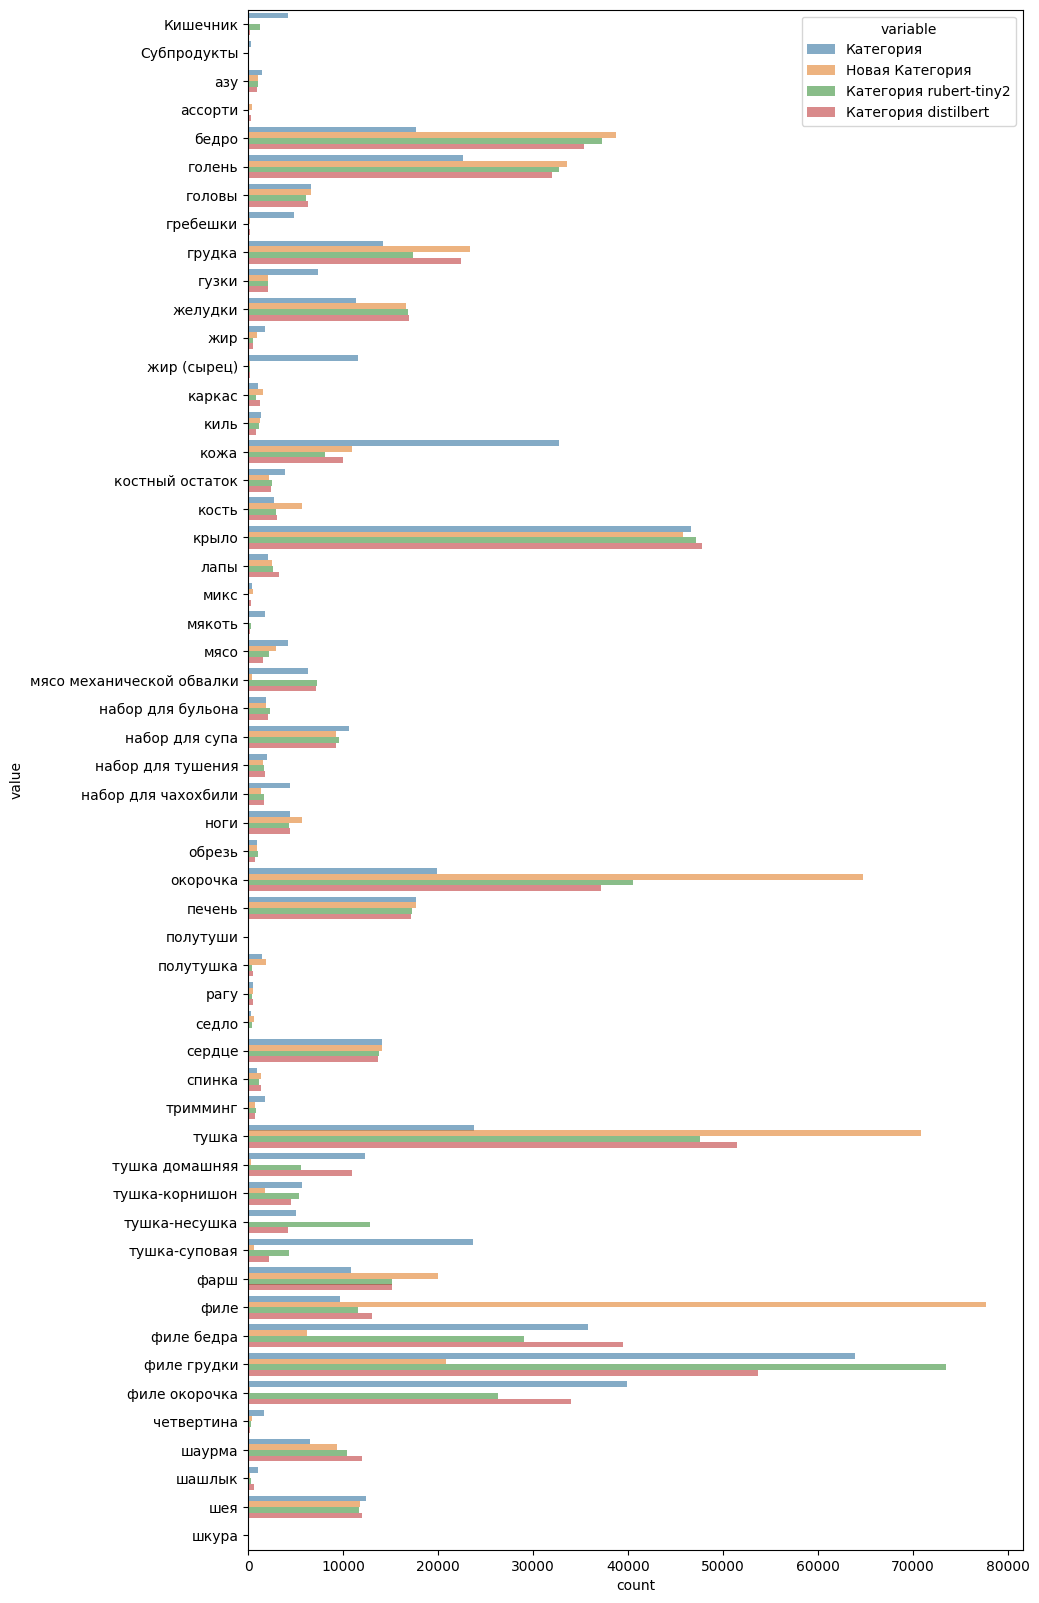

In [13]:
data = df.melt(value_vars=['Категория', 'Новая Категория', 'Категория rubert-tiny2', 'Категория distilbert'])
names = list(data['value'].unique())
names.sort()
plt.figure(figsize=(10, 20))
sns.countplot(y='value', data=data, hue='variable', alpha=0.6, order=names)
plt.show()

Модель обучалась на всеех датасетах, поэтому можно будет использовать одну модель для разных категорий, при добавлении какой-то новой категории модель желательно дообучить на ней. Можно сравнить предсказания модели с предсказаниями ChatGPT на примере датасета с свиньями. 

In [14]:
pig_df = pd.read_csv('data\monitorings_archive\Свинина.csv')
pig_cls_df = pd.read_csv('data\categories\Свинина_разрубы.csv', sep=';')

cls_names = pig_cls_df['value'].unique().tolist()

model_loaded = SentenceTransformer('models\\rubert-tiny2', device=DEVICE)
model_loaded.eval()

cls_names_ = [clear_for_bert(name) for name in cls_names]
cls_embeddings = model_loaded.encode(cls_names_)

def preds_sim(text):
    text_embedding = model_loaded.encode(text)
    preds_similarity = cosine_similarity(text_embedding.reshape(1, -1), cls_embeddings)
    max_pos = np.argmax(preds_similarity)
    return cls_names[max_pos]

pig_df['Описание bert'] = pig_df['Описание'].progress_apply(clear_for_bert)
pig_df['rubert-tiny2'] = pig_df['Описание bert'].progress_apply(preds_sim)

No sentence-transformers model found with name models\rubert-tiny2. Creating a new one with mean pooling.
Some weights of BertModel were not initialized from the model checkpoint at models\rubert-tiny2 and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 276774/276774 [22:56<00:00, 201.11it/s]


In [15]:
pig_df.head(5)

,Наименование,Описание,Зам./ Охл.,Страна,Упаковка,Наличие,Партия,Условия поставки,Цена,Компания,...,E-mail,Дата,federal_okrug,Сорт/Категория,Сертификация,Категория,Новая Категория,Конечная категория,Описание bert,rubert-tiny2
0,Свинина,Вырезка,зам,Бразилия,18 кг.,Заказ,от 500 кг..,Возм. доставка/ безнал,350.20,СОЗВЕЗДИЕ МСК,...,olkhludnev@mail.ru,2015-01-14,NaN,NaN,NaN,вырезка,вырезка,вырезка,вырезка,вырезка
1,Свинина,Ноги,зам,Франция,10 кг.,Склад,от кор.,Самовывоз,63.25,"АРСЕНАЛ, ООО",...,operac4@optpro.ru,2015-01-14,NaN,NaN,NaN,ноги,ноги,ноги,ноги,ноги
2,Свинина,Ноги,зам,Импорт,вес,Склад,NaN,Возм. доставка,72.00,МАКСЛАЙН,...,"sales23@maksfish.com, shtaketvseti@mail.ru, gu...",2015-01-14,NaN,NaN,NaN,ноги,ноги,ноги,ноги,ноги
3,Свинина,Ноги,зам,Россия,инд.вес,Склад,от 5 тонн,Возм. доставка,48.00,АГРОПРОДТОРГ,...,agroprodtorg@mail.ru,2015-01-14,NaN,NaN,NaN,ноги,ноги,ноги,ноги,ноги
4,Свинина,Ноги (23-25кг),зам,Россия,вес,Заказ,от кор.,Возм. доставка,65.55,ЭКОР-ФИШ,...,svetlana@ekorfish.ru,2015-01-14,NaN,2 сорт,NaN,ноги,ноги,ноги,ноги кг,ноги


In [16]:
model_1_to_gpt = len(pig_df[pig_df['Конечная категория'] == pig_df['Категория']])
model_2_to_gpt = len(pig_df[pig_df['Конечная категория'] == pig_df['Новая Категория']])
gpt_to_bert = len(pig_df[pig_df['Конечная категория'] == pig_df['rubert-tiny2']])

print(f'совпадений между gpt и 1 моделью: {model_1_to_gpt} / {round(model_1_to_gpt/len(pig_df), 4) * 100}%')
print(f'совпадений между gpt и 2 моделью {model_2_to_gpt} / {round(model_2_to_gpt/len(pig_df), 4) * 100}%')
print(f'совпадений между gpt и rubert-tinny2 : {gpt_to_bert} / {round(gpt_to_bert/len(pig_df), 4) * 100}%')

совпадений между gpt и 1 моделью: 223926 / 80.91000000000001%
совпадений между gpt и 2 моделью 254892 / 92.09%
совпадений между gpt и rubert-tinny2 : 260824 / 94.24%


Дополнительно можем отдельной колонкой выводить K наиболее похожих предсказаний, если они немного меньше самого уверенного предсказания

In [ ]:
threshold = 0.05
K=3

def preds_sim(text):
    # получение эмбеддинга описания
    text_embedding = model_loaded.encode(text)
    # сравнение косинусного сходства
    preds_similarity = cosine_similarity(text_embedding.reshape(1, -1), cls_embeddings)[0]

    # сортировка по наиболее уверенным предсказаниям
    max_indexses =  np.argpartition(preds_similarity, K+1)
    max_prob = preds_similarity[max_indexses[-1]]
    
    # поиск предсказаний которые отличаются от самого увренного не боле чем на 5%
    result = [cls_names[max_indexses[-1]]]

    for i in max_indexses[-K:-1]:
        candidate_prob = preds_similarity[i]
        if max_prob - candidate_prob <= threshold:
            result.append(cls_names[i])

    if len(result) > 1:
        return result[0], result[1:]
    return result[0], None

pig_df['rubert-tiny2'], pig_df['most similar'] = zip(*pig_df['Описание bert'].progress_apply(preds_sim))

100%|██████████| 276774/276774 [23:38<00:00, 195.14it/s]


In [18]:
pig_df[['Описание', 'Категория', 'Новая Категория', 'Конечная категория', 'rubert-tiny2', 'most similar']][22:44]

,Описание,Категория,Новая Категория,Конечная категория,rubert-tiny2,most similar
22,Ноги,ноги,ноги,ноги,ноги,None
23,Мясо котлетное (50/50)в/у,мясо,мясо,мясо,котлетные части (котлета),[мясо]
24,Мясо котлетное (80/20),мясо,мясо,мясо,котлетные части (котлета),[мясо]
25,Мясо котлетное (80/20) в/у,мясо,мясо,мясо,котлетные части (котлета),[мясо]
26,Мясо котлетное (90/10),мясо,мясо,мясо,котлетные части (котлета),[мясо]
27,Мясо котлетное (90/10) в/у,мясо,мясо,мясо,котлетные части (котлета),[мясо]
28,Мясо котлетное 90/10,мясо,мясо,мясо,котлетные части (котлета),[мясо]
29,Мясо котлетное 90/10,мясо,мясо,мясо,котлетные части (котлета),[мясо]
30,Мясо котлетное 90/10,мясо,мясо,мясо,котлетные части (котлета),[мясо]
31,Мясо котлетное 90/10,мясо,мясо,мясо,котлетные части (котлета),[мясо]
